In [1]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math
import pickle
from pathlib import Path

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

import statsmodels.api as sm
import pmdarima as pm

# Extension csv process

In [2]:
with open("/glade/work/stevenxu/FAIR_models/arima_list_emission_extension2.pkl", "rb") as f:
    arima_list = pickle.load(f)

In [3]:
csv_path = "/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/extensions_1750-2500.csv"
extension_csv = pd.read_csv(csv_path)

startyear = 2023
endyear = 2500

arima_forecasts = {}
no_emission_species = ['Solar',
 'Volcanic',
 'Aerosol-radiation interactions',
 'Aerosol-cloud interactions',
 'Ozone',
 'Light absorbing particles on snow and ice',
 'Stratospheric water vapour',
 'Land use',
 'Equivalent effective stratospheric chlorine',
 'c-C4F8']

def specie_emission_baseline(specie):  # to find the baseline for emissions
    row = extension_csv.loc[(extension_csv["variable"] == specie) & (extension_csv["scenario"] == 'medium-extension')].iloc[0]
    numeric_row = row.drop(labels=["scenario", "region", "variable", "unit"])
    numeric_row.index = numeric_row.index.astype(float)
    values_before_2023 = numeric_row[numeric_row.index < startyear]
    min_val = values_before_2023.min()
    return min_val

for specie in extension_csv["variable"].unique():
    if specie not in no_emission_species:
        model = arima_list[specie]
        arima_value, arima_CI = model.predict(n_periods=endyear-startyear+1, return_conf_int=True)
        arima_forecasts[specie] = [arima_value, arima_CI[:,0], arima_CI[:,1]]
        # making negative to zero
        arima_forecasts[specie] = np.maximum(arima_forecasts[specie], specie_emission_baseline(specie))



/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:1

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:1

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:1

In [4]:
years_before = [y + 0.5 for y in range(1750, startyear)]    
years_after  = [y + 0.5 for y in range(startyear, endyear + 1)]
arima_scenarios = ['ARIMA_mean', 'ARIMA_low', 'ARIMA_high']
region = "World"

rows = []
for specie in extension_csv["variable"].unique():
    for scenario_index, scenario in enumerate(arima_scenarios):
        unit = extension_csv.loc[(extension_csv["variable"] == specie) & (extension_csv["scenario"] == 'medium-extension'), "unit"].iloc[0]
        row = [scenario, 'World', specie, unit]
        for year in years_before:
            value = extension_csv.loc[(extension_csv["variable"] == specie) & (extension_csv["scenario"] == 'medium-extension'), str(year)].iloc[0]
            row.append(value)
        for year_index, year in enumerate(years_after):
            if specie in arima_forecasts.keys():
                value = arima_forecasts[specie][scenario_index][year_index]
            else:
                value = extension_csv.loc[(extension_csv["variable"] == specie) & (extension_csv["scenario"] == 'medium-extension'), str(year)].iloc[0]
            row.append(value)
        rows.append(row)

rowdf = pd.DataFrame(rows)
rowdf.columns = extension_csv.columns
extension_csv = pd.concat([extension_csv, rowdf], ignore_index=True)

In [5]:
extension_csv

,scenario,region,variable,unit,1750.5,1751.5,1752.5,1753.5,1754.5,1755.5,...,2491.5,2492.5,2493.5,2494.5,2495.5,2496.5,2497.5,2498.5,2499.5,2500.5
0,high-overshoot,World,BC,Mt BC/yr,2.096766,2.071972,2.067178,2.070382,2.098586,2.097789,...,1.081420,1.081420,1.081420,1.081420,1.081420,1.081420,1.081420,1.081420,1.081420,1.081420
1,high-overshoot,World,C2F6,kt C2F6/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,high-overshoot,World,C3F8,kt C3F8/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,high-overshoot,World,C4F10,kt C4F10/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,high-overshoot,World,C5F12,kt C5F12/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,ARIMA_low,World,VOC,Mt VOC/yr,60.622840,59.691733,59.366595,59.634416,60.880206,60.436960,...,307.934546,308.306433,308.678459,309.050623,309.422925,309.795365,310.167942,310.540656,310.913506,311.286491
506,ARIMA_high,World,VOC,Mt VOC/yr,60.622840,59.691733,59.366595,59.634416,60.880206,60.436960,...,557.500906,558.136330,558.771615,559.406762,560.041770,560.676641,561.311375,561.945973,562.580434,563.214759
507,ARIMA_mean,World,c-C4F8,kt cC4F8/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
508,ARIMA_low,World,c-C4F8,kt cC4F8/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
origional = pd.read_csv(csv_path)
configs = pd.read_csv('/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/species_configs_properties_calibration1.4.1.csv')
orig_species = set(origional["variable"].astype(str).str.strip())
config_species = set(configs["name"].astype(str).str.strip())
missing_in_csv = sorted(config_species - orig_species)

rows = []
for specie in missing_in_csv:
    for scenario in extension_csv['scenario'].unique():
        row  = [scenario, 'World', specie, f'kt {specie}/yr']
        for i in range(755-4):
            row.append(0)
        rows.append(row)

missingdf = pd.DataFrame(rows)
missingdf.columns = extension_csv.columns
extension_csv = pd.concat([extension_csv, missingdf], ignore_index=True)
extension_csv

,scenario,region,variable,unit,1750.5,1751.5,1752.5,1753.5,1754.5,1755.5,...,2491.5,2492.5,2493.5,2494.5,2495.5,2496.5,2497.5,2498.5,2499.5,2500.5
0,high-overshoot,World,BC,Mt BC/yr,2.096766,2.071972,2.067178,2.070382,2.098586,2.097789,...,1.08142,1.08142,1.08142,1.08142,1.08142,1.08142,1.08142,1.08142,1.08142,1.08142
1,high-overshoot,World,C2F6,kt C2F6/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
2,high-overshoot,World,C3F8,kt C3F8/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
3,high-overshoot,World,C4F10,kt C4F10/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
4,high-overshoot,World,C5F12,kt C5F12/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,medium-extension,World,Volcanic,kt Volcanic/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
606,medium-overshoot,World,Volcanic,kt Volcanic/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
607,ARIMA_mean,World,Volcanic,kt Volcanic/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
608,ARIMA_low,World,Volcanic,kt Volcanic/yr,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [7]:
extension_csv.to_csv('/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/extensions_1750-2500_with_arima.csv')

# Model fitting

In [8]:
f = FAIR(ch4_method="Thornhill2021")
f.define_time(1750, 2300, 1)  # start, end, step

scenarios = [
    "high-extension",
    "high-overshoot",
    "medium-overshoot",
    "medium-extension",
    "low",
    "verylow",
    "verylow-overshoot",
    'ARIMA_mean', 'ARIMA_low', 'ARIMA_high'
]

#scenarios = ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp534-over', 'ssp585']
f.define_scenarios(scenarios)
fair_params_1_4_1_file = '/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/calibrated_constrained_parameters_calibration1.4.1.csv'
df_configs = pd.read_csv(fair_params_1_4_1_file, index_col=0)
configs = df_configs.index  # this is used as a label for the "config" axis
f.define_configs(configs)
fair_species_configs_1_4_1_file = '/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/species_configs_properties_calibration1.4.1.csv'
species, properties = read_properties(filename=fair_species_configs_1_4_1_file)
f.define_species(species, properties)
f.allocate()

In [9]:
f.fill_from_csv(
    emissions_file="/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/extensions_1750-2500_with_arima.csv",
    forcing_file='/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/volcanic_solar_with_arima.csv',
)

In [10]:
fill(
    f.forcing,
    f.forcing.sel(specie="Volcanic") * df_configs["forcing_scale[Volcanic]"].values.squeeze(),
    specie="Volcanic",
)
fill(
    f.forcing,
    f.forcing.sel(specie="Solar") * df_configs["forcing_scale[Solar]"].values.squeeze(),
    specie="Solar",
)
f.fill_species_configs(fair_species_configs_1_4_1_file)
f.override_defaults(fair_params_1_4_1_file)
initialise(f.concentration, f.species_configs["baseline_concentration"])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)
initialise(f.ocean_heat_content_change, 0)

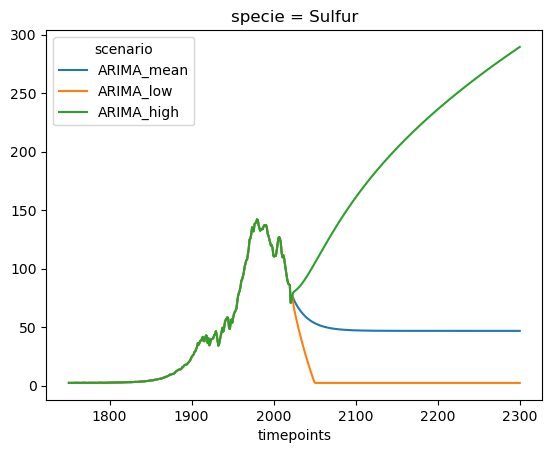

In [11]:
specie = 'Sulfur'
f.emissions.sel(specie = specie).isel(scenario = slice(-3,None)).mean(dim = 'config').plot(hue = 'scenario') 

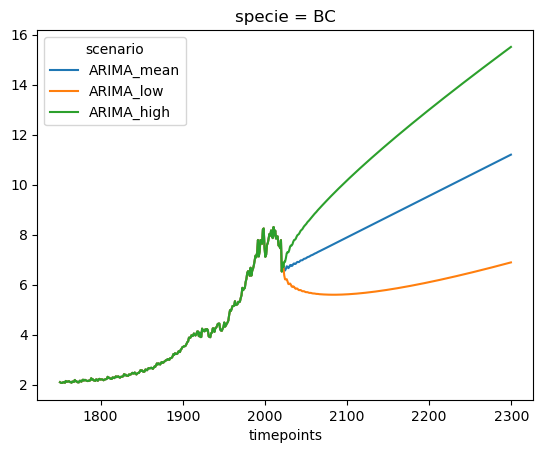

In [12]:
specie = 'BC'
f.emissions.sel(specie = specie).isel(scenario = slice(-3,None)).mean(dim = 'config').plot(hue = 'scenario') 

# Run

In [13]:
f.run()

Running 8410 projections in parallel:   0%|          | 0/550 [00:00<?, ?timesteps/s]

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(


/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(


...

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packa

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packa

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packa

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packa

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/fair/gas_cycle/ch4_lifetime.py:50: RuntimeWarning: invalid value encountered in log
  np.log(
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packa

In [14]:
save_path = "/glade/work/stevenxu/FAIR_models/fair_arima_extension2.pkl"
with open(save_path, "wb") as save:
    pickle.dump(f, save)